In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
df = pd.read_csv("data_moods.csv")
df.head()

,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


In [23]:
# Remove duplicates
df = df.drop_duplicates(subset=['id'])

# Remove missing mood values
df = df.dropna(subset=['mood'])

# Convert mood to proper format
df['mood'] = df['mood'].str.capitalize()

In [24]:
print(df['mood'].unique())

['Happy' 'Sad' 'Energetic' 'Calm']


In [25]:
def recommend_by_mood(selected_mood, n=5):
    
    mood_songs = df[df['mood'] == selected_mood]
    
    # Sort by popularity for better recommendations
    mood_songs = mood_songs.sort_values(by='popularity', ascending=False)
    
    return mood_songs[['name', 'artist', 'album', 'popularity']].head(n)

In [26]:
print(" Happy Songs:")
print(recommend_by_mood("Happy", 5))

 Happy Songs:
                                     name             artist  \
14                                 Africa               TOTO   
531                            Take on Me               a-ha   
434                       Pumped Up Kicks  Foster The People   
236                       Highway to Hell              AC/DC   
235  Here Comes The Sun - Remastered 2009        The Beatles   

                       album  popularity  
14                   Toto IV          84  
531     Hunting High and Low          84  
434                  Torches          84  
236          Highway to Hell          83  
235  Abbey Road (Remastered)          83  


In [27]:
print("Sad Songs:")
print(recommend_by_mood("Sad", 5))

Sad Songs:
                      name         artist  \
674   lovely (with Khalid)  Billie Eilish   
680  when the party's over  Billie Eilish   
683     you broke me first     Tate McRae   
177                Falling   Harry Styles   
24               All of Me    John Legend   

                                        album  popularity  
674                      lovely (with Khalid)          88  
680  WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?          87  
683                        you broke me first          87  
177                                 Fine Line          87  
24      Love In The Future (Expanded Edition)          85  


In [28]:
print(" Energetic Songs:")
print(recommend_by_mood("Energetic", 6))

 Energetic Songs:
                         name                    artist  \
91                 Chop Suey!          System Of A Down   
289       Killing In The Name  Rage Against The Machine   
129           Dani California     Red Hot Chili Peppers   
154                   Duality                  Slipknot   
600                  Uprising                      Muse   
257  I'm Not Okay (I Promise)       My Chemical Romance   

                                                 album  popularity  
91                                            Toxicity          79  
289  Rage Against The Machine - XX (20th Anniversar...          78  
129                                   Stadium Arcadium          77  
154                      Vol. 3: The Subliminal Verses          76  
600                                     The Resistance          75  
257                     Three Cheers for Sweet Revenge          73  


In [29]:
print("Calm Songs:")
print(recommend_by_mood("Calm", 4))

Calm Songs:
              name               artist           album  popularity
328           Lost              Annelie            Lost          64
168  Escaping Time     Benjamin Martins        Floating          60
120      Curiosity          Beau Projet       Curiosity          60
545     The Choice  Gustavo Santaolalla  The Last of Us          59


In [30]:
def precision_recall_at_k(recommended_songs, actual_songs, k):
    
    recommended_at_k = recommended_songs[:k]
    
    relevant = set(actual_songs)
    recommended = set(recommended_at_k)
    
    true_positives = len(recommended & relevant)
    
    precision = true_positives / k
    recall = true_positives / len(relevant) if len(relevant) > 0 else 0
    
    return precision, recall

In [31]:
actual = list(df[df['mood']=="Happy"]['name'][:10])
recommended = list(recommend_by_mood("Happy", 5)['name'])

precision, recall = precision_recall_at_k(recommended, actual, 5)

print("Precision@5:", precision)
print("Recall@5:", recall)

Precision@5: 0.2
Recall@5: 0.1


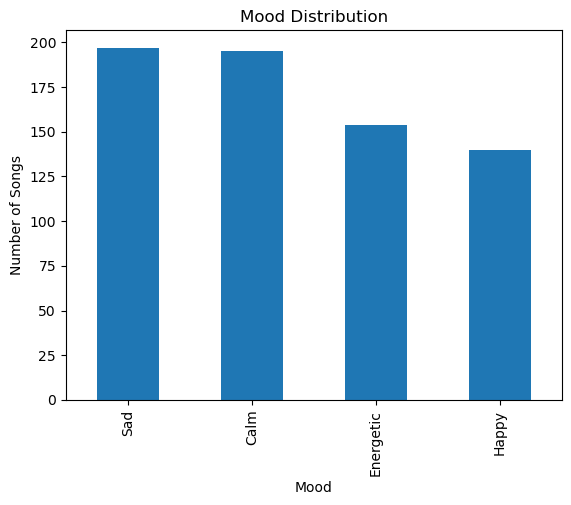

In [32]:

plt.figure()
df['mood'].value_counts().plot(kind='bar')
plt.title("Mood Distribution")
plt.xlabel("Mood")
plt.ylabel("Number of Songs")
plt.show()

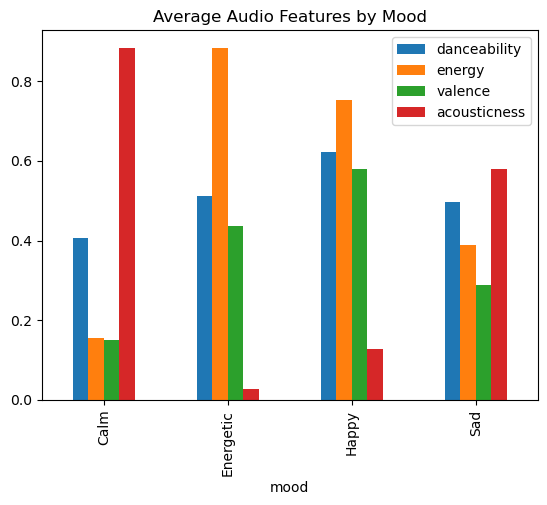

In [33]:
features = ['danceability','energy','valence','acousticness']

mood_features = df.groupby('mood')[features].mean()

mood_features.plot(kind='bar')
plt.title("Average Audio Features by Mood")
plt.show()